#Topics :Percentiles, IQR, Outlier Detection

**Percentiles**

In [29]:
import numpy as np
data = [10,20,30,40,50,60,70,80,90,100]
print("q1 :",np.percentile(data,25))    #Quantile 1
print("q2 :",np.percentile(data, 50))   #Quantile 2
print("q3 :",np.percentile(data,75))    #quantile 3

q1 : 32.5
q2 : 55.0
q3 : 77.5


IQR Outlier Detection

In [30]:
#interquartile (q3-q1)
q1 = np.percentile(data,25)
q3 = np.percentile(data,75)

iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 +1.5*iqr
outliers = [x for x in data if x<lower or x>upper]
print("iqr:",iqr ,"lower:",lower , "upper: ",upper,"outliers:",outliers)

iqr: 45.0 lower: -35.0 upper:  145.0 outliers: []


In [31]:
import pandas as pd
df = pd.DataFrame({
    'hours_studied': [1,2,3,4,5,6,7,8],
    'exam_score':    [45,52,58,65,72,78,85,91]
})

In [32]:
print(df.corr())

               hours_studied  exam_score
hours_studied       1.000000    0.999831
exam_score          0.999831    1.000000


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
salaries = np.concatenate([
    np.random.normal(50000, 8000, 95),
    [150000, 180000, 200000, 25000, 22000]
])
df = pd.DataFrame({'salary': salaries})
print(df['salary'].describe)

<bound method NDFrame.describe of 0      53973.713224
1      48893.885591
2      55181.508305
3      62184.238851
4      48126.773002
          ...      
95    150000.000000
96    180000.000000
97    200000.000000
98     25000.000000
99     22000.000000
Name: salary, Length: 100, dtype: float64>


In [34]:
q1 = np.quantile(df.salary,0.25)
q2 = np.quantile(df.salary,0.50)
q3 = np.quantile(df.salary,0.75)
iqr = q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = [x for x in df['salary'] if x<lower or x>upper]
print("q1:",q1,"q2:",q2,"q3:",q3,"iqr:",iqr,"lower:",lower,"upper:",upper,"outliers:",len(outliers),outliers )

q1: 45099.520817413366 q2: 48984.3496657623 q3: 54478.71283919753 iqr: 9379.192021784162 lower: 31030.732784737123 upper: 68547.50087187377 outliers: 6 [29042.039167282044, 150000.0, 180000.0, 200000.0, 25000.0, 22000.0]


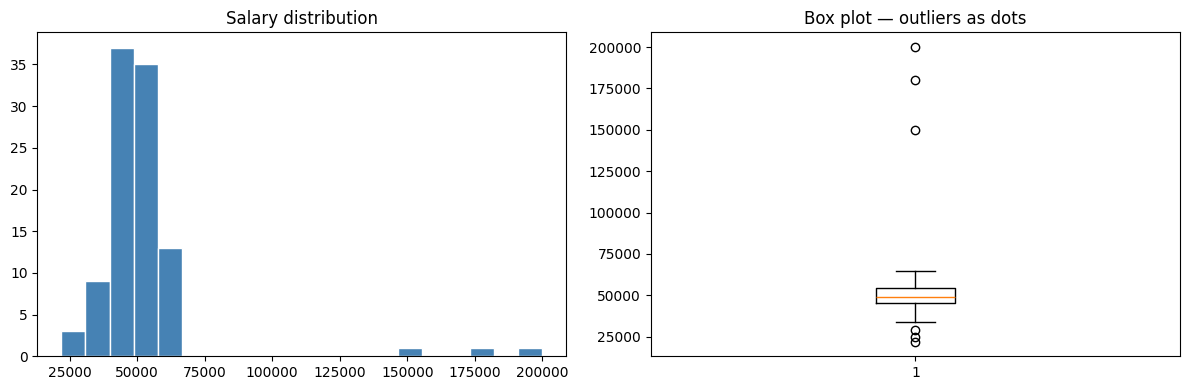

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['salary'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution')
axes[1].boxplot(df['salary'])
axes[1].set_title('Box plot — outliers as dots')
plt.tight_layout()
plt.show()